# Customer Retention Project with Cohort, RFM Analysis

This project analyze customer retention using historical transaction-level data from an online retail store. The objective is to provide data-driven insights and tailor marketing strategies.

The analysis is conducted using two widely adopted analytical frameworks:
* **Cohort Analysis** – Evaluates customer retention rates over time by grouping customers based on their first purchase period and tracking their subsequent purchasing behavior.
* **RFM Analysis** – Segments customers based on three key metrics:
    * Recency: Number of days since the customer's most recent purchase
    * Frequency: Number of purchases made by the customer
    * Monetary: Total amount spent by the customer

The project follows four main phases:
* **1. Data Understanding** – Exploring the dataset structure, business context, and key variables.
* **2. Data Cleaning** – Handling missing values, duplicates, invalid records, and data quality issues.
* **3. Cohort Analysis** – Preparing and analyzing retention cohorts to identify customer retention trends over time.
* **4. RFM Analysis** – Calculating RFM metrics and segmenting customers to support targeted marketing initiatives.

## 1. Data Understanding 

In [1]:
# import library
import pandas as pd

# Load the file with the correct encoding
file_path = r"C:\Users\hp\Desktop\VA Folder\Data\Project\Python - Online Retail\Online Retail.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1",parse_dates=['InvoiceDate'])

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


The dataset is structured at the *transaction-line item level* sharing the same *`InvoiceNo`*, *`InvoiceDate`*, and *`CustomerID`*. So same Customer, Invoice no can appear in multiple rows if the customer bought multiple products in that same Invoice.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


The data type is acceptable, except for CustomerID as it should be int64, I will change the type in later steps.
*"InvoiceDate"* type has been previously changed to datetime type when reading the file.

In [3]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

Overall, the data shows there are ~4,300 customers from 38 countries, ~4,000 SKU selling
When compare with total no of Invoice 25,900, the data showing some gaps in *'InvoiceDate'* recording, *'Quantity'* purchased.
Some *'StockCode'* is missing as well.

## 2. Data Cleaning

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

135,080 customer ID records are missing. Since this is a Customer Retention Analysis, a row without a CustomerID is completely useless so I will drop these rows. Null *'Desciprtion'* doesn't affect the analysis so I will keep as is.

In [5]:
# Check the null CustomerID rows 

df[df['CustomerID'].isnull()].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [6]:
# 1. Drop all null CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# 2. Convert the column type to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 3. Verify that the changes took effect
df_clean.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  str           
 1   StockCode    406829 non-null  str           
 2   Description  406829 non-null  str           
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.9 MB


In [7]:
# Filter out rows where Quantity or UnitPrice is less than or equal to 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean.shape

(397884, 8)

In [8]:
# Check no of rows before dropping duplicated rows 
rows_before_duplicates = len(df_clean)

# Dropping duplicated rows 
df_clean = df_clean.drop_duplicates()

# Check no of rows after dropping duplicated rows & print results 
rows_after_duplicates = len(df_clean)
duplicates_dropped = rows_before_duplicates - rows_after_duplicates
print(f"➡️ Total duplicate rows dropped: {duplicates_dropped:,}")
df_clean.shape

➡️ Total duplicate rows dropped: 5,192


(392692, 8)

Summary of Data Cleaning Impact:
* Initial Rows: 541,909
* Rows after dropping missing Customer IDs,Filter Quantity & Unit price: 397,884
* Rows after removing duplicates: 392,692
* Total data retained: 72.4%

## 3. Cohort Analysis

For time-based cohort analysis, following columns are required:
* Invoice Month: Month that customers make purchase
* Cohort Month: Month that customers make the very first purchase
* Cohort index: number of months between the Cohort Month and the Invoice Month
* Total new customers of each month
* Retention Index = Unique returned customer at each Cohort index / Total new customer of the Starting Month

In [9]:
df_clean['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [10]:
df_clean['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [11]:
# Step 1: Create function to get 1st day of the month 
def get_month(x):
    return pd.Timestamp(year=x.year, month=x.month, day=1)

df_clean['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01


In [12]:
# Step 2: Get the 1st month when the customer made their 1st purchase
df_clean['CohortMonth'] = df_clean.groupby(['CustomerID'])['InvoiceMonth'].transform('min')
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01


In [13]:
# Step 3: Calculate the Cohort Index by Month
def get_date_int(dataframe, column):
    year = dataframe[column].dt.year
    month = dataframe[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df_clean, "InvoiceMonth")
cohort_year, cohort_month = get_date_int(df_clean, "CohortMonth")

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df_clean['CohortIndex'] = years_diff * 12 + months_diff

In [14]:
# Step 4: Aggregate unique customers per cohort month and index
cohort_data = df_clean.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()

# Pivot the data to create a matrix view
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This cohort analysis calculating customer’s first purchase and their subsequent purchases.
My goal is to create a **Customer Retention Matrix** showing percentage so I need to conduct one more step as below.

In [15]:
# Select the first column (Month 0) as the total cohort size
cohort_size = cohort_counts.iloc[:,0]

# Divide the entire matrix by the cohort sizes along the rows to get percentages
retention = cohort_counts.divide(cohort_size, axis=0)
retention = retention.round(3) * 100
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


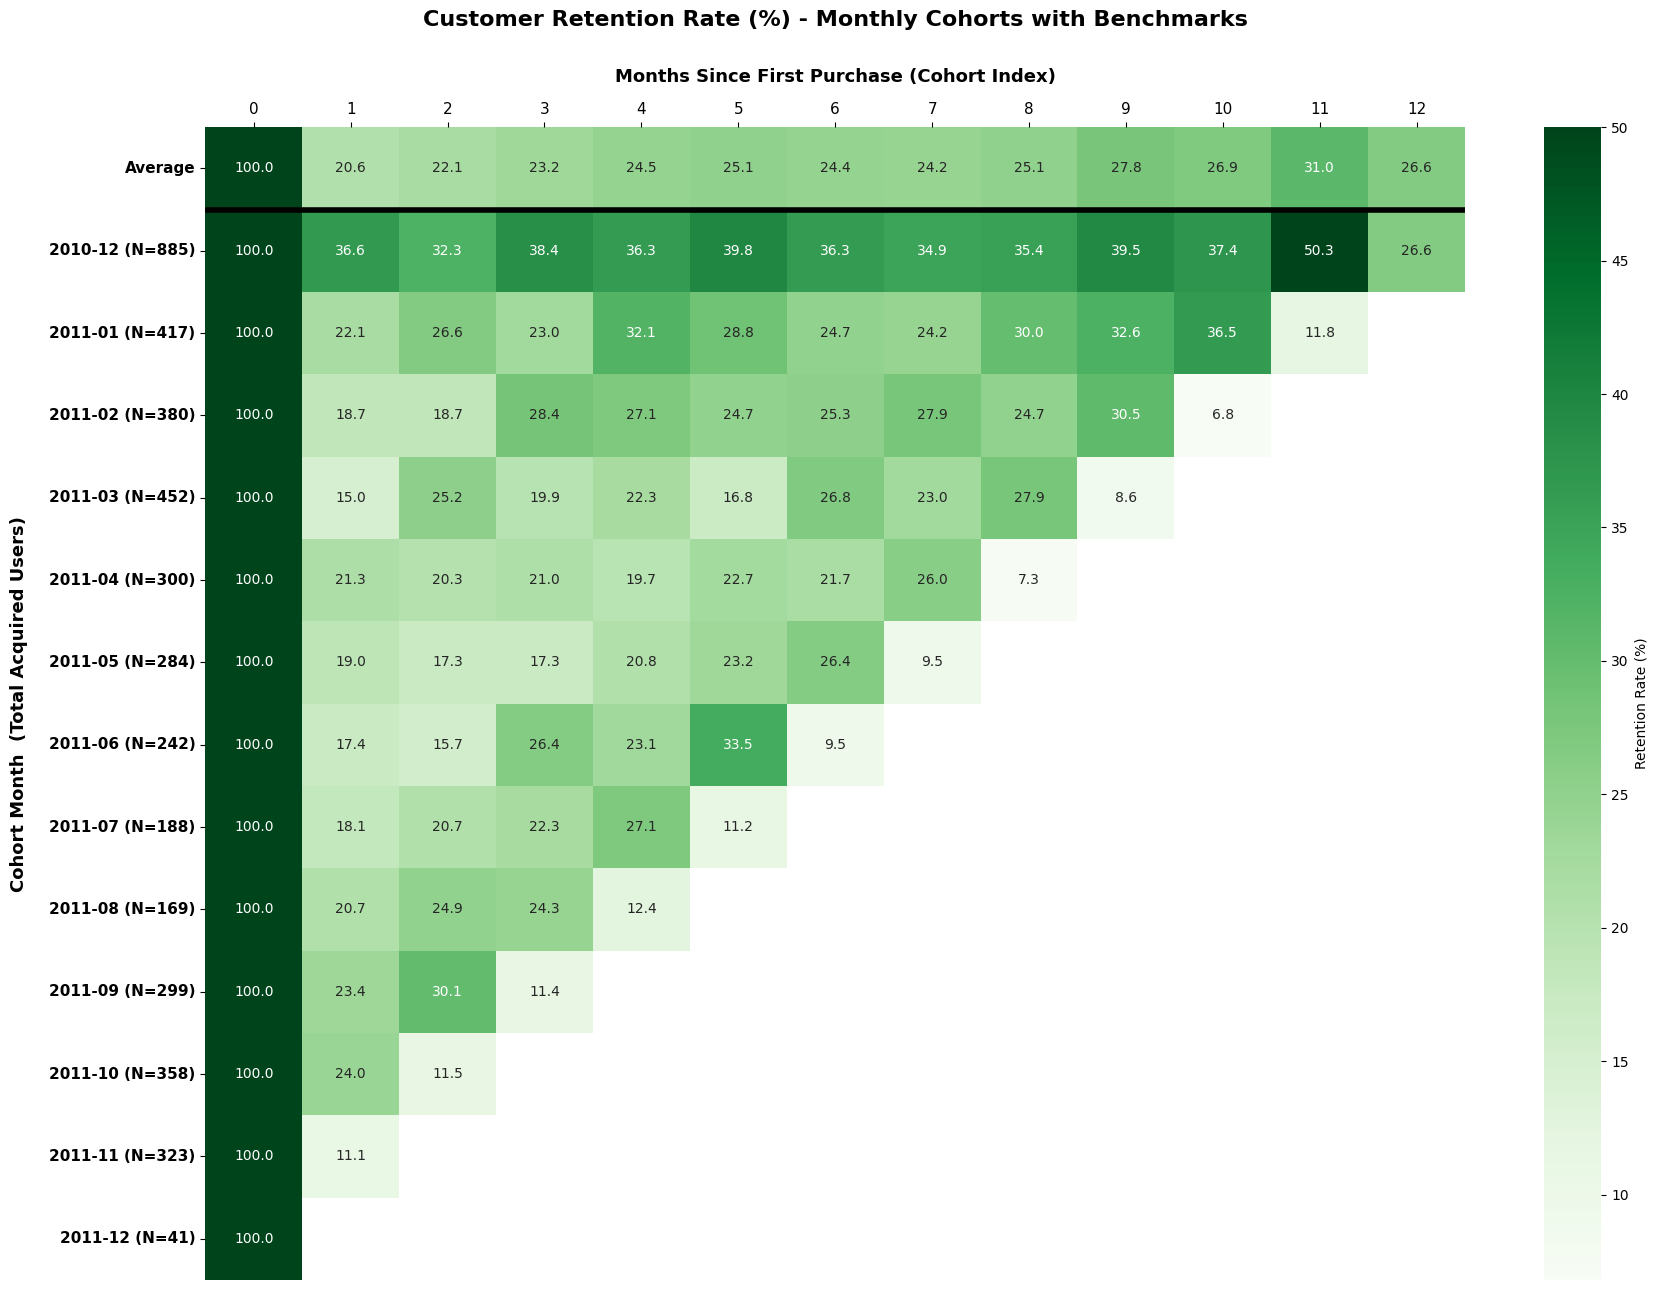

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation
retention_df = retention.copy()
retention_df.index = pd.to_datetime(retention_df.index).strftime('%Y-%m')

# Calculate the lifecycle average (ignoring Month 0's 100%)
avg_lifecycle = retention_df.iloc[:, 1:].mean()

# Construct the 'Average' row data
avg_row = pd.DataFrame([[100.0] + list(avg_lifecycle.values)], 
                       columns=retention_df.columns, 
                       index=['Average'])

# Combine them by putting the Average row ON TOP
retention_df = pd.concat([avg_row, retention_df])

# Create the clean, combined Y-axis text strings using pandas map
formatted_sizes = cohort_size.map(lambda x: f" (N={int(x):,})")
new_y_labels = ['Average'] + list(retention_df.index[1:] + formatted_sizes)

# Visualization
plt.figure(figsize=(18, 13))
plt.title('Customer Retention Rate (%) - Monthly Cohorts with Benchmarks', fontsize=16, fontweight='bold', pad=30)

# Plot the heatmap using Greens palette
sns.heatmap(data=retention_df,
            annot=True,          
            fmt='.1f',           
            cmap='Greens',          
            vmax=50,             
            cbar_kws={'label': 'Retention Rate (%)'})

# Add the bold black horizontal separator line below the Average Baseline row
plt.axhline(y=1, color='black', linewidth=4)

# Keep the X-axis names at the top
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top')

plt.ylabel('Cohort Month  (Total Acquired Users)', fontsize=13, fontweight='bold', labelpad=15)
plt.xlabel('Months Since First Purchase (Cohort Index)', fontsize=13, fontweight='bold', labelpad=15)

# Pass our cleanly generated labels to the Y-axis (Guarantees zero overlapping text)
plt.gca().set_yticklabels(new_y_labels, rotation=0, fontsize=11, fontweight='bold')
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

### Cohort Analysis

To get a quick overview, the retention plummets from 100% in Month 0 to an **Average rate of ~21% in Month 1**. However, **post-month 1, retention rate remains between 20% and 30%** across all lifecycles, showing the demand is quite stable & predictable.  
*(Note: Data for 2011-12 has been excluded from behavioral analysis, as the dataset only records 9 days)*

**1. Horizontal View (Customer Lifespan):** showing the Customer Lifespan performance in each month. Overvall, **12-2010 is the highest-performing segment**, consistently maintaining a 35%–50% retention rate throughout its entire lifespan. This suggests a highly unique, high-value customer persona (such as wholesale B2B buyers) was captured during this initial launch window. 

**2. Vertical View (Seasonality):** Comparing columns at Month 1 reveals a clear seasonal U-shape. **Spring & Summer groups demand showing poor retention** with the lowest point of 15% in 2011-03. However, **the demand strongly recover in late autumn, winter time** climbing back to 24% in 2011-10, indicating that year-end marketing channels captured higher-intent shoppers.

**3. Diagonal (Specific Month):**  **Late autumn, Winter timeframe (2011-9 to 2011-11) once again show increasing demand** regardless of how long a customer had been with the company, everyone returned and purchased at a much higher rate during this time. This signals a highly successful site-wide event, such as a major Black Friday promotion or early holiday campaign, that successfully re-engaged old, sleeping users.
  
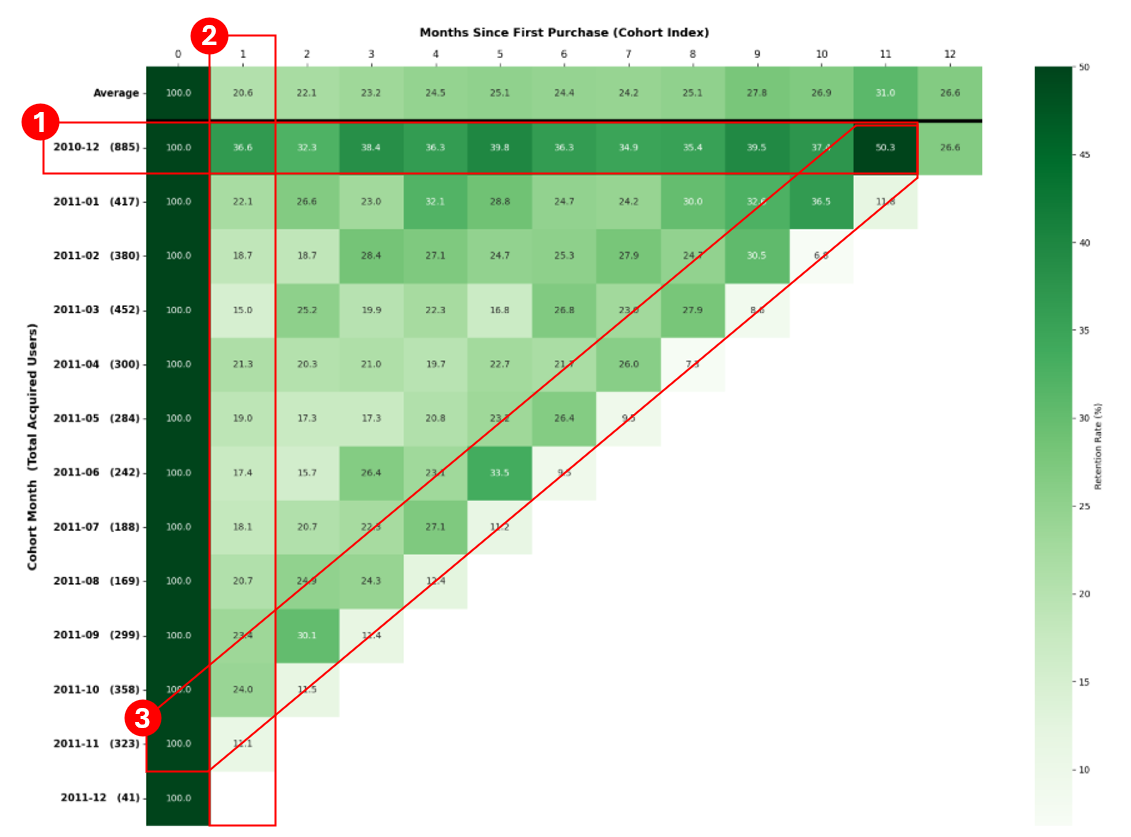

## 4. RFM Analysis

To make RFM analysis, I need these columns:
* Recency (R): max invoice date - invoice date
* Frequency (F): number of time return
* Monetary (M): total spending
* TotalValue: total value of each order Quantity * UnitPrice

In [17]:
# Prepare data for RFM dataframe
df_clean['TotalValue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['Recency'] = (df_clean['InvoiceDate'].max() - df_clean['InvoiceDate']).dt.days

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,TotalValue,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,2010-12-01,0,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,0,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,2010-12-01,0,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,0,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,2010-12-01,0,20.34,373


In [18]:
# Building RFM dataframe
df_rfm = df_clean.groupby(['CustomerID']).agg({
                            'Recency' : 'min',
                            'InvoiceNo' : 'nunique',
                            'TotalValue' : 'sum'})

df_rfm.columns = ['Recency','Frequency','Monetary']

df_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [19]:
# Summarize RFM data
df_rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,91.54,4.27,2048.69
std,100.01,7.70,8985.23
min,0.00,1.00,3.75
25%,17.00,1.00,306.48
50%,50.00,2.00,668.57
75%,141.00,5.00,1660.60
max,373.00,209.00,280206.02


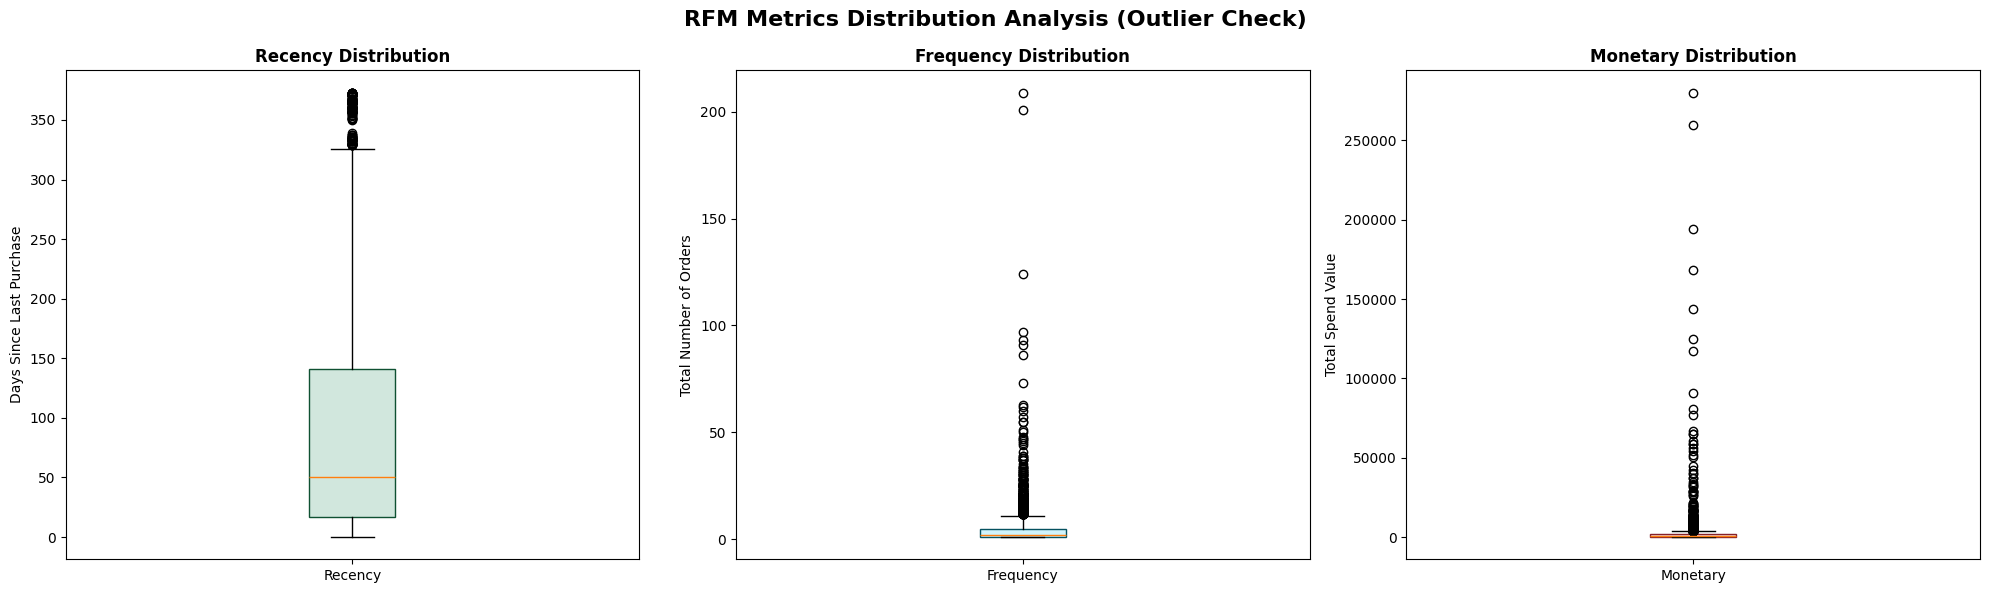

In [20]:
# Create Boxplot charts to visualize the distribution of RFM metrics 

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('RFM Metrics Distribution Analysis (Outlier Check)', fontsize=16, fontweight='bold')

# 1. Recency Box Plot
axes[0].boxplot(df_rfm['Recency'], patch_artist=True, 
                boxprops=dict(facecolor='#d1e7dd', color='#0f5132'))
axes[0].set_title('Recency Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Days Since Last Purchase')
axes[0].set_xticklabels(['Recency'])

# 2. Frequency Box Plot
axes[1].boxplot(df_rfm['Frequency'], patch_artist=True,
                boxprops=dict(facecolor='#cff4fc', color='#055160'))
axes[1].set_title('Frequency Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Number of Orders')
axes[1].set_xticklabels(['Frequency'])

# 3. Monetary Box Plot
axes[2].boxplot(df_rfm['Monetary'], patch_artist=True,
                boxprops=dict(facecolor='#f8d7da', color='#842029'))
axes[2].set_title('Monetary Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Total Spend Value')
axes[2].set_xticklabels(['Monetary'])

# Apply tight layout to prevent overlap between graphs
plt.tight_layout()
plt.show()

**Recency (Days since last purchase):**
* **Distribution:** The data is right-skew but well distributed compared to other metrics. Overall average recency is 91 days (~3 months) from the last purchase, while 50% of customers purchased within the last 50 days.
* **Outliers:** There are a few outliers at the very top (beyond 320+ days), representing completely dormant customers who haven't bought anything in nearly a year (max 373 days).
  
**Frequency(Total number of orders):** 
* **Distribution:** The distribution is extremely right skew with 75% of customer made 5 or fewer orders.
* **Outliers:** There are a high volume of extreme outliers spreading all the way up to a maximum of 209 orders. These number represent a tiny, elite group of highly loyal or wholesale-like repeat buyers.

**Monetary (Total spend value):** 
* **Distribution:** Massive variance of order value results in the most severe right skew distribution. While 75% of the customers spent less than 1,660.60 units (with a median spend of just 668.57)
* **Outliers:** With the max extreme outlier peak at 280,206.02 value per order (400+ times vs median), these customers have extremely high spending. 

In [21]:
# Create RFM Scorecard

# Create copies to safely assign scores
rfm_scores = df_rfm.copy()

# 1. Recency Score: Lower days = Higher/Better score (Labels are inverted: 4 to 1)
rfm_scores['R_Score'] = pd.qcut(rfm_scores['Recency'], q=4, labels=[4, 3, 2, 1])

# 2. Frequency Score: Higher orders = Higher/Better score (Labels: 1 to 4)
rfm_scores['F_Score'] = pd.qcut(rfm_scores['Frequency'].rank(method = 'first'), q=4, labels=[1, 2, 3, 4]) 

# 3. Monetary Score: Higher spend = Higher/Better score (Labels: 1 to 4)
rfm_scores['M_Score'] = pd.qcut(rfm_scores['Monetary'], q=4, labels=[1, 2, 3, 4])

# 4. Combine into an RFM String Segment (e.g., "444" or "121")
rfm_scores['RFM_Type'] = rfm_scores['R_Score'].astype(str) + \
                         rfm_scores['F_Score'].astype(str) + \
                         rfm_scores['M_Score'].astype(str)

# 5. Calculate a simple numeric Index score for broad ranking
rfm_scores['RFM_Score'] = rfm_scores[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

rfm_scores.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Type,RFM_Score
CustomerID,,,,,,,,
12346,325,1,77183.60,1,1,4,114,6
12347,1,7,4310.00,4,4,4,444,12
12348,74,4,1797.24,2,3,4,234,9
12349,18,1,1757.55,3,1,4,314,8
12350,309,1,334.40,1,1,2,112,4


In [22]:
rfm_scores.describe().round(1)

,Recency,Frequency,Monetary,RFM_Score
count,4338.0,4338.0,4338.0,4338.0
mean,91.5,4.3,2048.7,7.5
std,100.0,7.7,8985.2,2.8
min,0.0,1.0,3.8,3.0
25%,17.0,1.0,306.5,5.0
50%,50.0,2.0,668.6,7.0
75%,141.0,5.0,1660.6,10.0
max,373.0,209.0,280206.0,12.0


In [23]:
# Define and Map the Customer Segments
def assign_segment(df):
    score = df['RFM_Score']
    if score == 12:
        return 'VIPs'
    elif score >= 10:
        return 'Loyal'
    elif score >=6:
        return 'Potential'
    elif score >=4:
        return 'At risk'
    else:
        return 'Lost'

# Apply segmentation mapping 
rfm_scores['Segment'] = rfm_scores.apply(assign_segment, axis=1)
rfm_scores['Segment'].value_counts()

Segment
Potential    1780
At risk       991
Loyal         778
VIPs          489
Lost          300
Name: count, dtype: int64

In [24]:
# Summarize the segmentation
segment_summary = rfm_scores.groupby('Segment').agg({
                            'Recency': 'mean',
                            'Frequency': 'mean',
                            'Monetary': ['mean', 'sum'],
                            'RFM_Score': 'count'
                            }).round(1)

segment_summary.columns = ['Avg Recency (Days)', 'Avg Frequency (Orders)', 'Avg Spend ($)', 'Total Revenue ($)', 'Customer Count']
segment_summary = segment_summary.sort_values(['Avg Spend ($)'], ascending=False)
segment_summary.head()

,Avg Recency (Days),Avg Frequency (Orders),Avg Spend ($),Total Revenue ($),Customer Count
Segment,,,,,
VIPs,6.4,15.5,9047.8,4424373.6,489
Loyal,26.8,6.4,3088.5,2402862.2,778
Potential,69.8,2.5,956.3,1702129.1,1780
At risk,170.4,1.2,312.3,309485.8,991
Lost,266.8,1.0,161.2,48358.2,300


In [25]:
# Further breakdown the segmentation into sub-segments, groupby Segment & rank by Total Revenue

sub_segment = rfm_scores.groupby(['Segment', 'RFM_Type']).agg({
    'Monetary': ['mean', 'sum'],  
    'RFM_Score': 'count' # Using CustomerID to avoid confusion with the old RFM_Score sum
}).reset_index()

# Flatten the MultiIndex column names explicitly
sub_segment.columns = ['Main Segment', 'RFM Type', 'Avg Revenue ($)', 'Total Revenue ($)', 'User Count']

# CALCULATE COMPANY REVENUE SHARE
total_company_revenue = rfm_scores['Monetary'].sum()
sub_segment['Company Revenue Share (%)'] = (sub_segment['Total Revenue ($)'] / total_company_revenue * 100).round(1)

# Round the numerical columns cleanly
sub_segment['Avg Revenue ($)'] = sub_segment['Avg Revenue ($)'].round(1)
sub_segment['Total Revenue ($)'] = sub_segment['Total Revenue ($)'].round(1)

# Assign segment order
custom_segment_order = ['Lost', 'At risk', 'Potential', 'Loyal customers', 'VIPs']

sub_segment['Main Segment'] = pd.Categorical(
    sub_segment['Main Segment'], 
    categories=custom_segment_order, 
    ordered=True
)

# Sort by Segment category first, then by Total Revenue, Avg Revenue descending within each group
top_sub_types = sub_segment.sort_values(['Main Segment', 'Total Revenue ($)','Avg Revenue ($)'], ascending=[True, False, False]) \
                           .groupby('Main Segment') \
                           .head(5) # Extracted Top 5 deep-dive cells per segment

top_sub_types

C:\Users\hp\AppData\Local\Temp\ipykernel_19672\3985534313.py:22: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  sub_segment['Main Segment'] = pd.Categorical(


,Main Segment,RFM Type,Avg Revenue ($),Total Revenue ($),User Count,Company Revenue Share (%)
9,Lost,111,161.2,48358.2,300,0.5
0,At risk,112,410.4,71005.8,173,0.8
3,At risk,122,451.5,58689.8,130,0.7
6,At risk,212,432.4,43673.2,101,0.5
1,At risk,113,996.6,36873.5,37,0.4
2,At risk,121,179.9,33455.8,186,0.4
37,Potential,234,2840.0,176079.8,62,2.0
36,Potential,233,1089.2,171006.0,157,1.9
49,Potential,333,1058.0,167161.6,158,1.9
24,Potential,134,6998.6,125975.6,18,1.4


### Strategic RFM Micro-Grouping

Based on the two analysis, I've groupped the customer database into 4 tactical micro-segments based on core buying patterns. Below table provide a summary executive to understand the customer groups, their behaviour and provide strategic actions to tackle each group:
| Tactical Group | Sample of Target RFM Types | Main Segment Origin | Avg Revenue Density | % of Co. Revenue | Primary Strategic Action |
| :--- | :--- | :--- | :---: | :---: | :--- |
| **Group 1: Core Support Engines (`x44` / `4x4`)** | `444`, `344`, `244`, `434`, `424` | VIPs / Loyal Customers | **High to Ultra-High** <br> *(Up to \$30,107)* | **70.3%** | **Retention & Frictionless VIP Care:** Focus on dedicated B2B account management, early access, and white-glove service. Avoid discount spam. |
| **Group 2: The Hidden Whales (`1x4` / `2x4`)** | `114`, `134`, `234` | Potential | **Ultra-High Spenders** <br> *(\$2,840 to \$10,440)* | **4.5%** | **High-Value Sales Win-Back:** Pass these exact Customer IDs directly to an inside sales team for direct phone/email outreach. Treat as corporate buyers. |
| **Group 3: The Nurture Middle Class (`x33` / `x12`)** | `233`, `333`, `112`, `122`, `212`, `121` | Potential / At Risk | **Moderate** <br> *(\$179 to \$1,089)* | **6.2%** | **Habit-Building Gamification:** Use automated cross-selling funnels, product bundles, and milestone rewards to push purchase frequency from 1–2 up to 4+. |
| **Group 4: The Dead Weight (`111`)** | `111` | Lost | **Floor Baseline** <br> *(\$161.2)* | **0.5%** | **Cost Suppression:** Completely exclude this list from paid remarketing channels (Google/Meta Ads) to save budget. Keep on low-cost automated email-only flows. |

Thank you for reading. This is the end of the project.